In [1]:
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from keras.applications import EfficientNetB0
from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

from pathlib import Path
from PIL import Image

2025-12-29 16:02:35.002121: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-29 16:02:36.264735: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-29 16:02:53.274004: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/mnt/c/Users/OMEN/Downloads/code/momo/lib/python3.12/site-packages/k

In [2]:
dataset_path = '/mnt/c/Users/OMEN/Downloads/code/FACE_EMOTION_RECOG/DATA/images'

In [3]:
from typing import Optional, List
def get_image_files(folder: Path) -> List[Path]:
    """Get all image files from a folder."""
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.gif')
    return [img for ext in extensions for img in folder.glob(ext)]


def collect_emotion_images(base_path: Path, target_classes: Optional[List[str]] = None) -> dict:
    """Collect images from emotion folders, optionally filtered by target classes."""
    emotion_folders = [f for f in base_path.iterdir() if f.is_dir()]
    
    # Filter by target classes if specified
    if target_classes:
        target_lower = {cls.lower() for cls in target_classes}
        emotion_folders = [f for f in emotion_folders if f.name.lower() in target_lower]
        
        if not emotion_folders:
            available = [f.name for f in base_path.iterdir() if f.is_dir()]
            raise ValueError(
                f"No folders found matching target classes: {target_classes}\n"
                f"Available folders: {available}"
            )
    
    if not emotion_folders:
        raise ValueError(f"No emotion folders found in {base_path}")
    
    # Collect images
    emotion_images = {}
    for folder in emotion_folders:
        image_files = get_image_files(folder)
        if image_files:
            emotion_images[folder.name] = image_files
            print(f"{folder.name}: {len(image_files)} images")
    
    if not emotion_images:
        raise ValueError("No images found in any emotion folder!")
    
    return emotion_images


def visualize_emotion_samples(
    base_path: str,
    samples_per_emotion: int = 5,
    target_classes: Optional[List[str]] = None,
    figsize_per_image: tuple = (3, 3)
) -> None:
    """
    Visualize random sample images from emotion folders.
    
    Args:
        base_path: Path to directory containing emotion folders
        samples_per_emotion: Number of random samples to display per emotion
        target_classes: List of specific emotions to display (None for all)
        figsize_per_image: Size of each image subplot (width, height)
    
    Example:
        visualize_emotion_samples(
            'DATA/images/train',
            samples_per_emotion=5,
            target_classes=['happy', 'sad']
        )
    """
    base_path = Path(base_path)
    
    if not base_path.exists():
        raise FileNotFoundError(f"Path does not exist: {base_path}")
    
    # Collect images
    emotion_images = collect_emotion_images(base_path, target_classes)
    print(f"\nFound {len(emotion_images)} emotion categories\n")
    
    # Create visualization
    num_emotions = len(emotion_images)
    fig, axes = plt.subplots(
        num_emotions,
        samples_per_emotion,
        figsize=(
            samples_per_emotion * figsize_per_image[0],
            num_emotions * figsize_per_image[1]
        )
    )
    
    # Ensure axes is 2D array
    axes = axes.reshape(num_emotions, samples_per_emotion)
    
    fig.suptitle('Random Samples from Emotion Categories', fontsize=16, fontweight='bold', y=0.995)
    
    # Plot images
    for row, (emotion, img_paths) in enumerate(emotion_images.items()):
        num_to_show = min(samples_per_emotion, len(img_paths))
        selected_imgs = random.sample(img_paths, num_to_show)
        
        for col in range(samples_per_emotion):
            ax = axes[row, col]
            ax.axis('off')
            
            if col < num_to_show:
                img = Image.open(selected_imgs[col])
                ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
                
                # Add emotion label as title on first image
                if col == 0:
                    ax.set_title(
                        emotion.upper(),
                        fontsize=14,
                        fontweight='bold',
                        loc='left',
                        pad=10
                    )
    
    plt.tight_layout()
    plt.show()

angry: 3993 images
disgust: 436 images
fear: 4103 images
happy: 7164 images
neutral: 4982 images
sad: 4938 images
surprise: 3205 images

Found 7 emotion categories



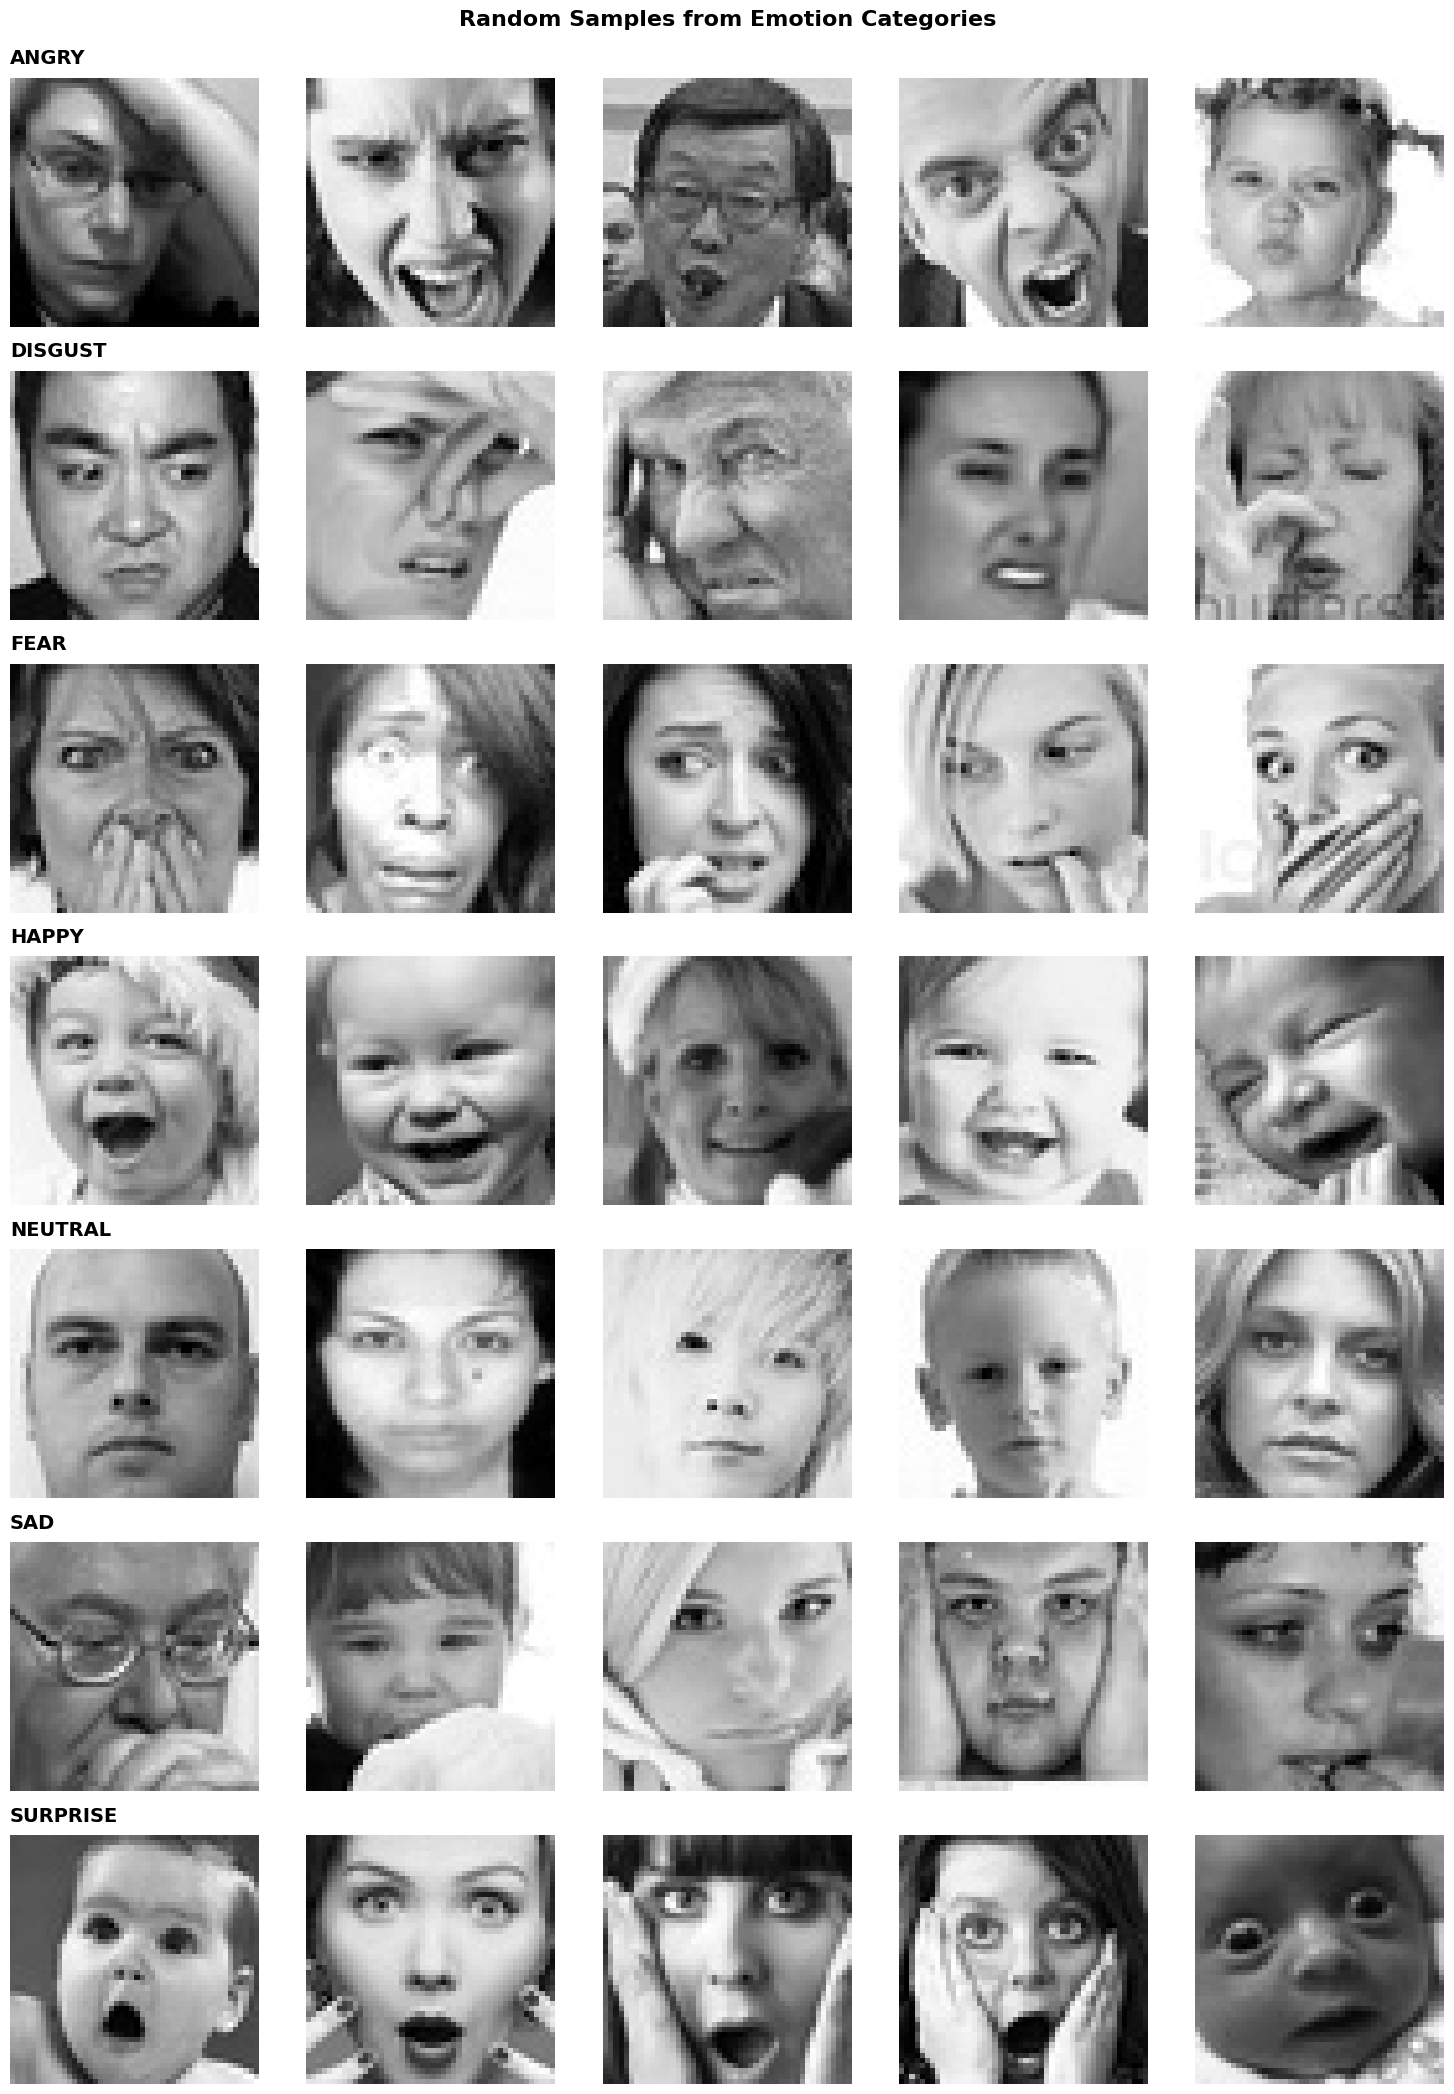

In [4]:
visualize_emotion_samples(base_path=dataset_path + '/train', samples_per_emotion=5, target_classes=None)

In [5]:
emotion_classes = sorted([f.name for f in Path('DATA/images/train').iterdir() if f.is_dir()])
print("Emotion Classes:", emotion_classes)

Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train", target_size=(224,224),
    batch_size=64, color_mode="grayscale", class_mode="categorical")

val_generator = val_datagen.flow_from_directory(
    dataset_path + "/validation", target_size=(224,224),
    batch_size=64, color_mode="grayscale", class_mode="categorical")

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✓ Using GPU: {gpus[0]}")
else:
    print("⚠️ No GPU found!")

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))

# Dataset is grayscale so we need to convert to 3 channels
inputs = tf.keras.Input(shape=(224,224,1))
x = tf.keras.layers.Conv2D(3, (3,3), padding='same')(inputs)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

✓ Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


I0000 00:00:1767042187.671401  320172 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,568 (15.48 MB)

 Trainable params: 4,016,545 (15.32 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [8]:
checkpoint = ModelCheckpoint("/mnt/c/Users/OMEN/Downloads/code/FACE_EMOTION_RECOG/MODEL/best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max")
earlystop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=30,
                    callbacks=[checkpoint, earlystop, lr_reducer])

Epoch 1/30


2025-12-29 16:03:48.336098: I external/local_xla/xla/service/service.cc:163] XLA service 0x7cfd04004250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-29 16:03:48.336133: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-12-29 16:03:49.463800: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-29 16:03:55.254316: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2025-12-29 16:04:06.535854: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k5=1,k6=0,k7=1,k10=0} for conv (f32[64,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,112,112]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=32, custom_c

258/451 ━━━━━━━━━━━━━━━━━━━━ 58s 302ms/step - accuracy: 0.2884 - loss: 1.7689

2025-12-29 16:08:07.742891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:08:07.963664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:08:08.181338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:08:08.398186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:08:08.511885: E external/local_xla/xla/service

451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.3361 - loss: 1.6699

2025-12-29 16:10:09.786814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:10:09.997488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:10:11.072249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:10:11.294085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:10:11.535431: E external/local_xla/xla/stream_

451/451 ━━━━━━━━━━━━━━━━━━━━ 428s 493ms/step - accuracy: 0.4234 - loss: 1.4807 - val_accuracy: 0.1008 - val_loss: 1.9871 - learning_rate: 1.0000e-04
Epoch 2/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 149s 330ms/step - accuracy: 0.5609 - loss: 1.1579 - val_accuracy: 0.1603 - val_loss: 8498.7939 - learning_rate: 1.0000e-04
Epoch 3/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 201s 328ms/step - accuracy: 0.6066 - loss: 1.0461 - val_accuracy: 0.1889 - val_loss: 1.8613 - learning_rate: 1.0000e-04
Epoch 4/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 150s 332ms/step - accuracy: 0.6370 - loss: 0.9728 - val_accuracy: 0.1722 - val_loss: 1.8833 - learning_rate: 1.0000e-04
Epoch 5/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 156s 346ms/step - accuracy: 0.6567 - loss: 0.9214 - val_accuracy: 0.1677 - val_loss: 3516.0361 - learning_rate: 1.0000e-04
Epoch 6/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 151s 335ms/step - accuracy: 0.6776 - loss: 0.8636 - val_accuracy: 0.2464 - val_loss: 1.7814 - learning_rate: 1.0000e-04
Epoch 7/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 143s 

In [21]:
# Improving model to increase its accuracy and reduce overfitting

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,  # Increased from 20
    width_shift_range=0.2,  # Increased from 0.1
    height_shift_range=0.2,  # Increased from 0.1
    horizontal_flip=True,
    zoom_range=0.2,  # random zoom
    shear_range=0.15,  # shear transformations
    brightness_range=[0.8, 1.2],  # brightness variation
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train", target_size=(224,224),
    batch_size=64, color_mode="grayscale", class_mode="categorical")

val_generator = val_datagen.flow_from_directory(
    dataset_path + "/validation", target_size=(224,224),
    batch_size=64, color_mode="grayscale", class_mode="categorical")

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✓ Using GPU: {gpus[0]}")
else:
    print("⚠️ No GPU found!")

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base model

# Dataset is grayscale so we need to convert to 3 channels
inputs = tf.keras.Input(shape=(224,224,1))
x = tf.keras.layers.Conv2D(3, (3,3), padding='same')(inputs)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

checkpoint = ModelCheckpoint("/mnt/c/Users/OMEN/Downloads/code/FACE_EMOTION_RECOG/MODEL/best_model2.keras", save_best_only=True, monitor="val_accuracy", mode="max")
earlystop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)

# Phase 1: Train only the top layers
model.compile(optimizer=Adam(1e-3), 
              loss="categorical_crossentropy", 
              metrics=["accuracy"])

history1 = model.fit(train_generator,
                     validation_data=val_generator,
                     epochs=20,
                     callbacks=[checkpoint, earlystop, lr_reducer])

# Phase 2: Fine-tune the last layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:  # Freeze all except last 30 layers
    layer.trainable = False

model.compile(optimizer=Adam(1e-5),  # Much lower learning rate
              loss="categorical_crossentropy", 
              metrics=["accuracy"])

history2 = model.fit(train_generator,
                     validation_data=val_generator,
                     epochs=25,
                     callbacks=[checkpoint, earlystop, lr_reducer])

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✓ Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 233s 409ms/step - accuracy: 0.6108 - loss: 1.0418 - val_accuracy: 0.2608 - val_loss: 1.8351 - learning_rate: 0.0010
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 155s 342ms/step - accuracy: 0.6386 - loss: 0.9681 - val_accuracy: 0.2583 - val_loss: 2.0236 - learning_rate: 0.0010
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 153s 338ms/step - accuracy: 0.6508 - loss: 0.9248 - val_accuracy: 0.1499 - val_loss: 8.9578 - learning_rate: 0.0010
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 151s 335ms/step - accuracy: 0.6688 - loss: 0.8840 - val_accuracy: 0.1786 - val_loss: 1.8940 - learning_rate: 0.0010
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 150s 333ms/step - accuracy: 0.7127 - loss: 0.7664 - val_accuracy: 0.1353 - val_loss: 1.9524 - le

In [18]:
model

<Functional name=functional, built=True>

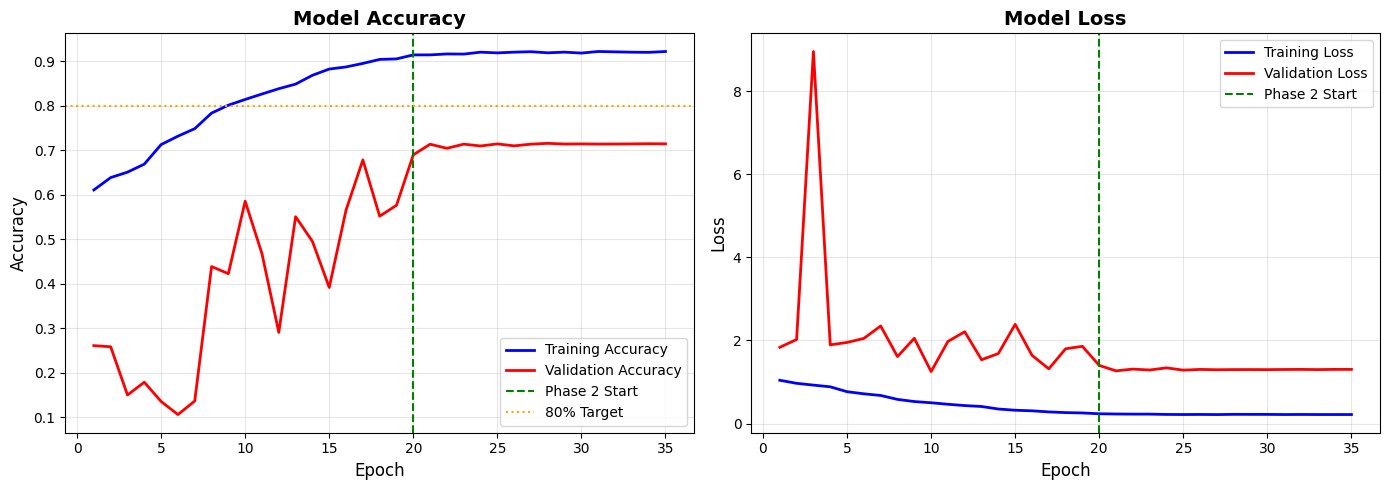


FINAL TRAINING RESULTS
Final Training Accuracy:   92.19%
Final Validation Accuracy: 71.44%
Final Training Loss:       0.2165
Final Validation Loss:     1.3029
Accuracy Gap:              20.75%


In [19]:
# Combine histories from both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(1, len(acc) + 1)
phase1_end = len(history1.history['accuracy'])

# Create figure with 2 subplots side by side
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
plt.axvline(x=phase1_end, color='green', linestyle='--', label='Phase 2 Start', linewidth=1.5)
plt.axhline(y=0.80, color='orange', linestyle=':', label='80% Target', linewidth=1.5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.axvline(x=phase1_end, color='green', linestyle='--', label='Phase 2 Start', linewidth=1.5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL TRAINING RESULTS")
print("="*60)
print(f"Final Training Accuracy:   {acc[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")
print(f"Accuracy Gap:              {abs(acc[-1] - val_acc[-1])*100:.2f}%")
print("="*60)


Evaluating on Training Set
451/451 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step

Confusion Matrix:
[[ 558   47  543  972  696  740  437]
 [  61    7   62  104   83   68   51]
 [ 569   57  559 1011  748  683  476]
 [ 982  113  956 1808 1269 1219  817]
 [ 671   83  719 1263  872  861  513]
 [ 668   95  723 1224  860  841  527]
 [ 451   41  426  792  544  543  408]]

Classification Report:
              precision    recall  f1-score   support

       angry       0.14      0.14      0.14      3993
     disgust       0.02      0.02      0.02       436
        fear       0.14      0.14      0.14      4103
       happy       0.25      0.25      0.25      7164
     neutral       0.17      0.18      0.17      4982
         sad       0.17      0.17      0.17      4938
    surprise       0.13      0.13      0.13      3205

    accuracy                           0.18     28821
   macro avg       0.15      0.15      0.15     28821
weighted avg       0.18      0.18      0.18     28821



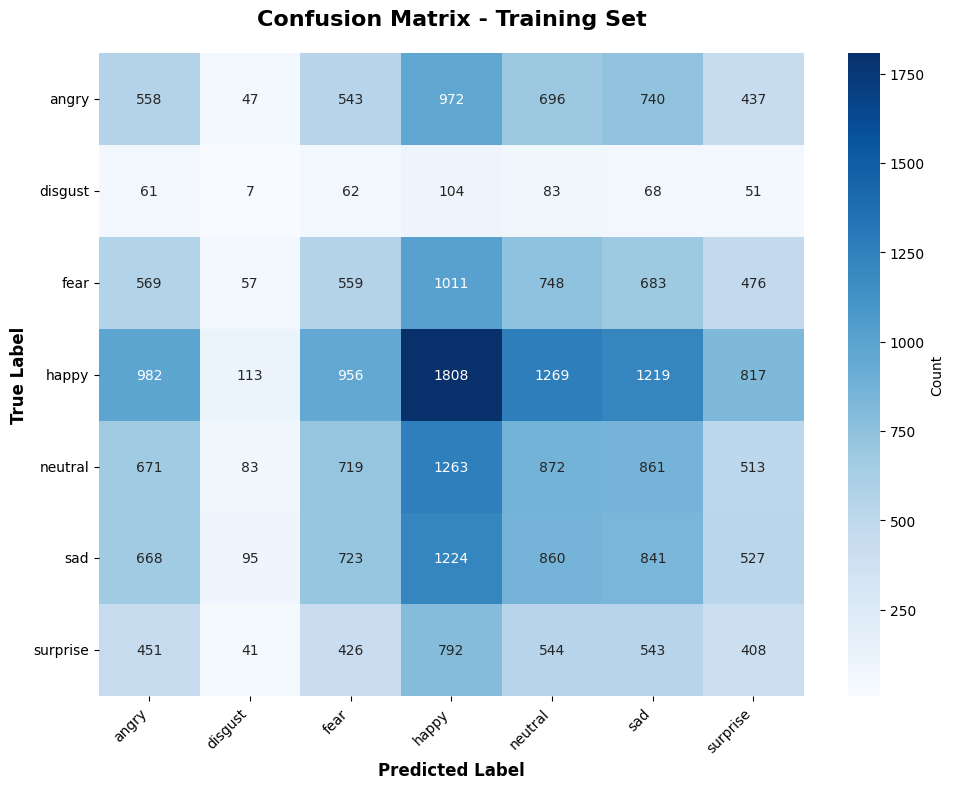


Evaluating on Validation Set
111/111 ━━━━━━━━━━━━━━━━━━━━ 30s 264ms/step

Confusion Matrix:
[[145   5 105 245 191 162 107]
 [ 16   1   8  29  23  17  17]
 [131  13 126 266 210 164 108]
 [258  21 239 477 330 310 190]
 [165  20 145 332 224 198 132]
 [154  20 132 294 219 207 113]
 [128  11  82 213 150 132  81]]

Classification Report:
              precision    recall  f1-score   support

       angry       0.15      0.15      0.15       960
     disgust       0.01      0.01      0.01       111
        fear       0.15      0.12      0.14      1018
       happy       0.26      0.26      0.26      1825
     neutral       0.17      0.18      0.17      1216
         sad       0.17      0.18      0.18      1139
    surprise       0.11      0.10      0.10       797

    accuracy                           0.18      7066
   macro avg       0.14      0.14      0.14      7066
weighted avg       0.18      0.18      0.18      7066



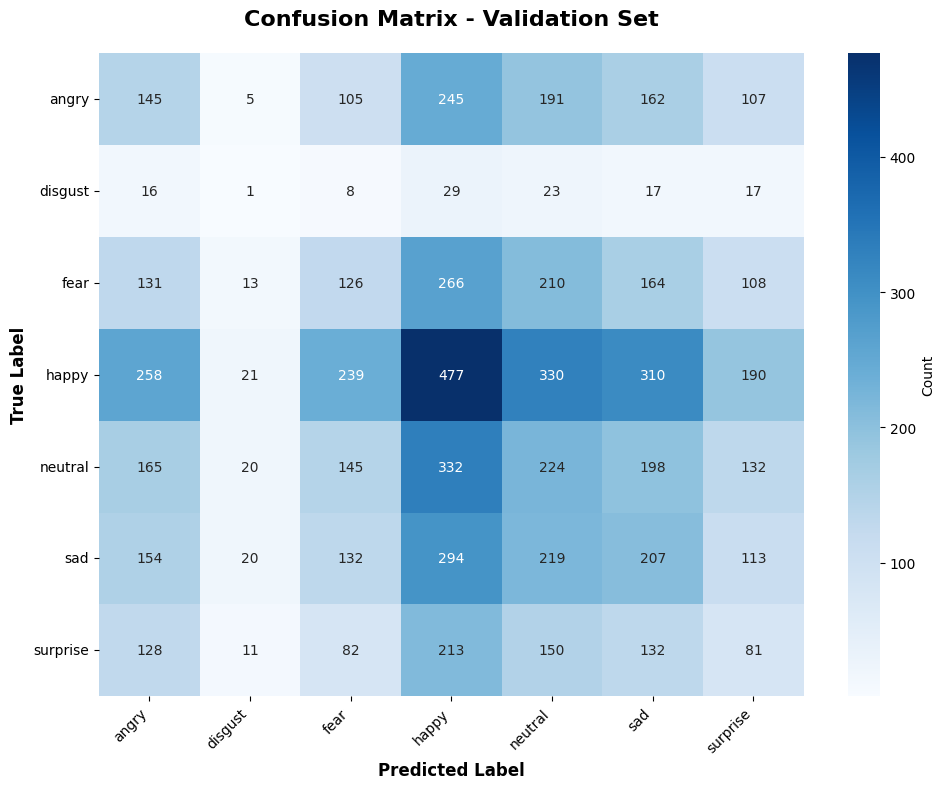

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_and_plot_confusion_matrix(model, dataset, dataset_name='Dataset', class_labels=None):
    """
    Evaluate model and plot confusion matrix with classification report
    
    Args:
        model: Trained Keras model
        dataset: Data generator (train/val/test set)
        dataset_name: Name for the plot title (e.g., 'Training', 'Validation', 'Test')
        class_labels: Dictionary mapping class indices to names (optional)
    """
    
    # Get predictions
    print(f"\n{'='*60}")
    print(f"Evaluating on {dataset_name} Set")
    print(f"{'='*60}")
    
    predictions = model.predict(dataset, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = dataset.classes
    
    # Get class labels
    if class_labels is None:
        class_labels = {v: k for k, v in dataset.class_indices.items()}
    
    target_names = [class_labels[i] for i in sorted(class_labels.keys())]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Print confusion matrix and classification report
    print('\nConfusion Matrix:')
    print(cm)
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix - {dataset_name} Set', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return cm, y_pred

# Usage
class_labels = {v: k for k, v in val_generator.class_indices.items()}

# Evaluate on all datasets
cm_train, pred_train = evaluate_and_plot_confusion_matrix(model, train_generator, 'Training', class_labels)
cm_val, pred_val = evaluate_and_plot_confusion_matrix(model, val_generator, 'Validation', class_labels)


2025-12-29 22:02:30.598464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 22:02:30.805800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 22:02:31.744964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 22:02:32.013147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 22:02:32.971364: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


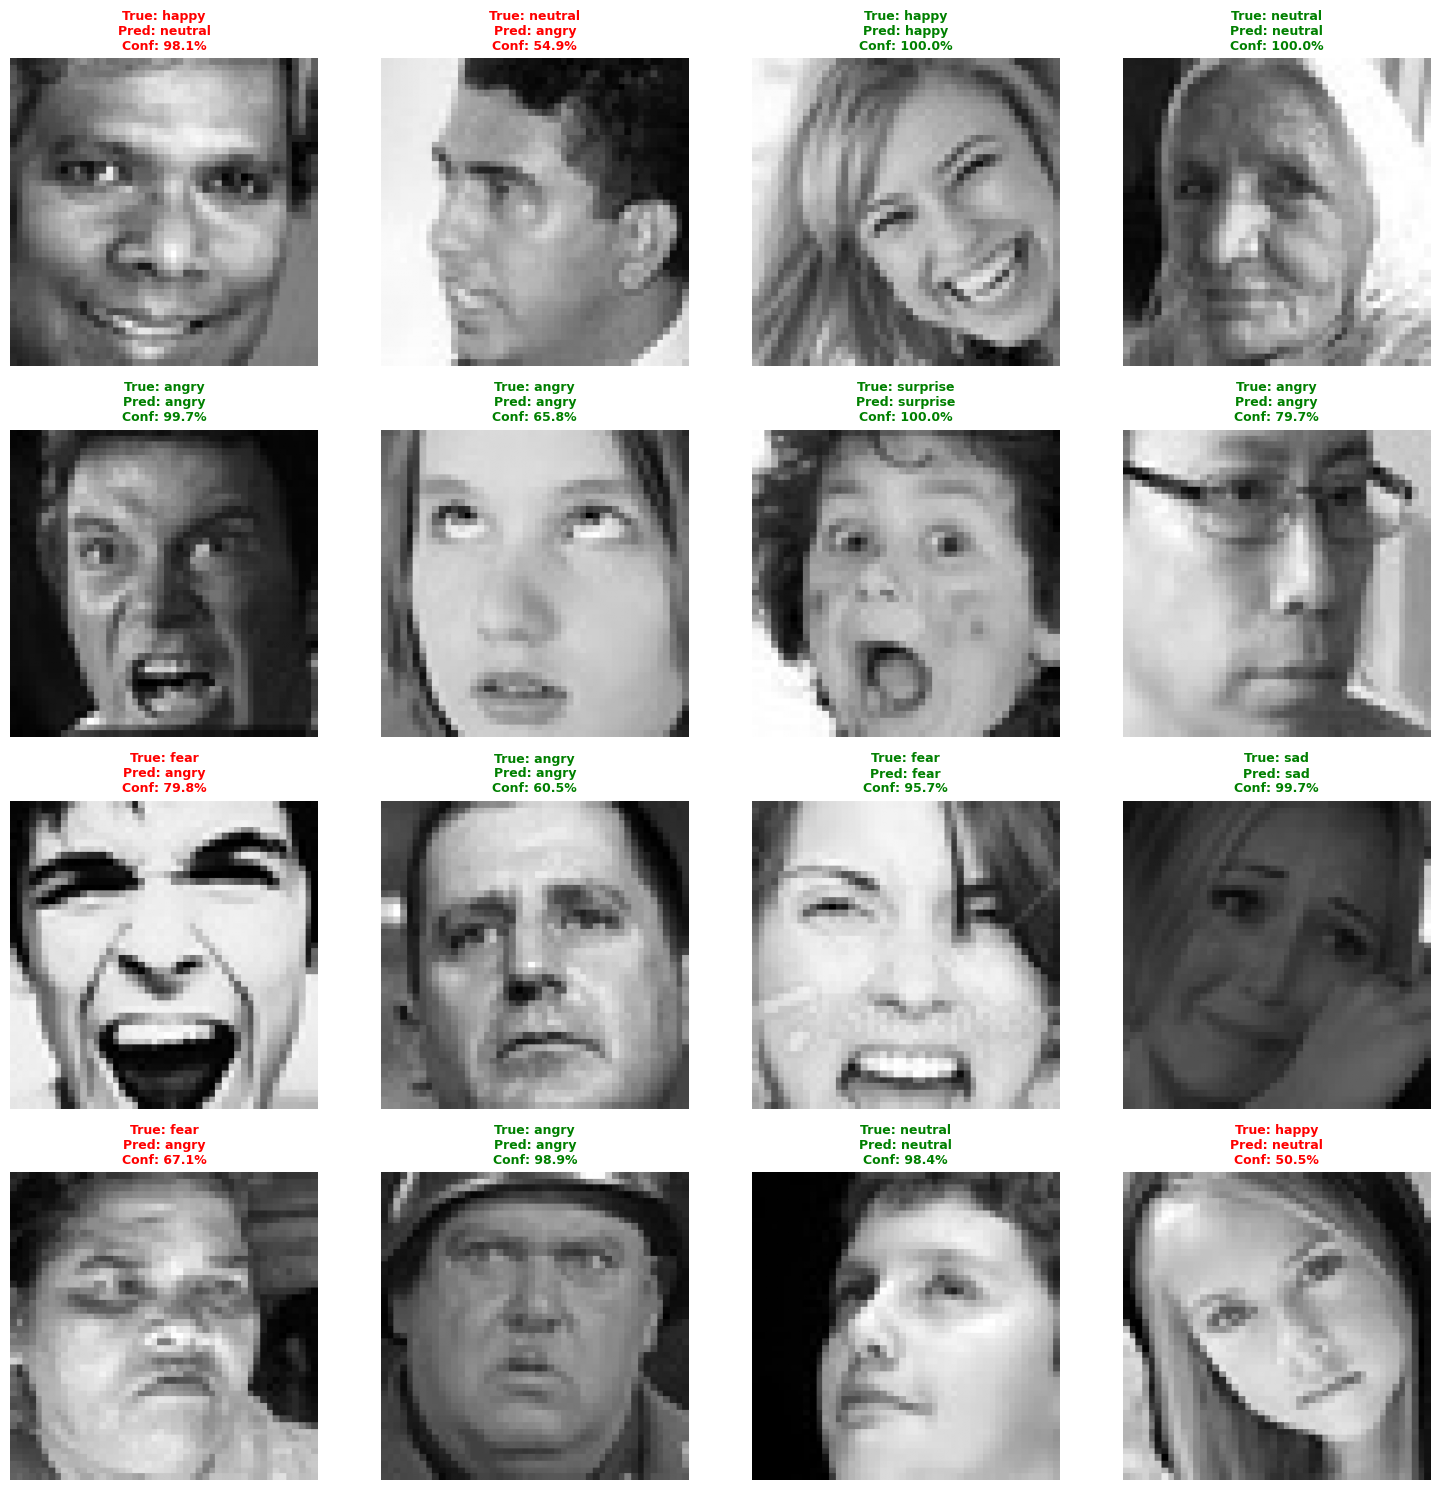

In [20]:
def visualize_sample_predictions(model, generator, class_names, num_images=16):
    """
    Display a grid of images with their predicted and true labels
    
    Args:
        model: Trained Keras model
        generator: ImageDataGenerator (validation or test)
        class_names: List of class names
        num_images: Number of images to display (default: 16)
    """
    # Get a batch of images
    images, true_labels = next(generator)
    
    # Make predictions
    predictions = model.predict(images[:num_images])
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(true_labels[:num_images], axis=1)
    
    # Calculate grid size
    grid_size = int(np.ceil(np.sqrt(num_images)))
    
    # Create figure
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    axes = axes.flatten()
    
    for idx in range(num_images):
        ax = axes[idx]
        
        # Display image (handle grayscale)
        img = images[idx]
        if img.shape[-1] == 1:
            ax.imshow(img[:, :, 0], cmap='gray')
        else:
            ax.imshow(img)
        
        # Get prediction confidence
        confidence = predictions[idx][predicted_classes[idx]] * 100
        
        # Prepare labels
        true_label = class_names[true_classes[idx]]
        pred_label = class_names[predicted_classes[idx]]
        
        # Color code: green for correct, red for incorrect
        color = 'green' if true_classes[idx] == predicted_classes[idx] else 'red'
        
        # Set title with prediction and confidence
        title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        ax.set_title(title, fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    
    # Hide extra subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
visualize_sample_predictions(model, val_generator, class_names, num_images=16)

In [10]:
# import tensorflow as tf
# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     tf.config.set_visible_devices(gpus[0], 'GPU')
#     tf.config.experimental.set_memory_growth(gpus[0], True)
#     print(f"✓ Using GPU: {gpus[0]}")
# else:
#     print("⚠️ No GPU found!")

# # Enable mixed precision for faster training 
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

# # model code
# base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
# base_model.trainable = False  # Freeze for faster training

# inputs = tf.keras.Input(shape=(224,224,1))
# x = tf.keras.layers.Conv2D(3, (3,3), padding='same')(inputs)
# x = base_model(x, training=False)
# x = GlobalAveragePooling2D()(x)
# x = Dropout(0.3)(x)
# outputs = Dense(len(class_names), activation="softmax", dtype='float32')(x)

# model = Model(inputs, outputs)
# model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
# model.summary()

In [11]:
# # Callbacks
# checkpoint = ModelCheckpoint("/mnt/c/Users/OMEN/Downloads/code/FACE_EMOTION_RECOG/MODEL/best_model.keras", 
#                             save_best_only=True, monitor="val_accuracy", mode="max")
# earlystop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
# lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)

In [12]:
# # Train
# history = model.fit(train_generator,
#                     validation_data=val_generator,
#                     epochs=30,
#                     callbacks=[checkpoint, earlystop, lr_reducer])